# ESN for Chaotic Dynamics

### Author: N. A. K. Doan (n.doan@imperial.ac.uk)
This notebook is heavily based on the one available [here](https://github.com/MagriLab/Tutorials/) created by Elise Özalp (elise.ozalp@imperial.ac.uk), Luca Magri (luca.magri@imperial.ac.uk). Edits have been made to streamline it with respect to the other notebook in this repository.

This notebook demonstrates the application of echo state networks (ESN) networks in learning chaotic dynamics of the Lorenz-63 system. Chaotic systems like Lorenz-63 exhibit complex behavior, making them challenging for modeling.
The Lorenz-63 system is a set of ordinary differential equations that describe a simplified atmospheric convection model. It is a classic example of a chaotic system, characterized by sensitive dependence on initial conditions.

Echo State Networks are a type of recurrent neural network (RNN), based on reservoir computing. We explore how ESNs can be applied to learn and predict the chaotic behavior inherent in systems like Lorenz-63.

Feel free to adapt and expand upon this structure to suit the specific details and findings of your analysis. 

In [ ]:
use_colab = False
if use_colab:
    !git clone -b main https://github.com/ndoan-icl/CYPHER_MLSchool_Brussels2026.git
    !pip install scikit-optimize
    # from google.colab import drive
    # drive.mount('/content/drive')

# 1 Loading librairies

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# from dynamicalsystems.equations import solve_rk4, lorenz63
# from dynamicalsystems.metrics import valid_prediction_time
if use_colab:
    from CYPHER_MLSchool_Brussels2026.esn.utils import errors, scalers
    from CYPHER_MLSchool_Brussels2026.esn.validation import validate, set_ESN    
else:
    from esn.utils import errors, scalers
    from esn.validation import validate, set_ESN
from esn.esn import ESN
import scipy.stats as stats
from typing import Optional

# 2. Load the dataset


In [ ]:
if use_colab:
    fld = './CYPHER_MLSchool_Brussels2026/'
else:
    fld = './'
np_file = np.load( fld + 'Lorenz_data/LorenzSys_Lorenz_data.npz')
X = np_file['X'] # Data
dt = np_file['dt']
t_split = np_file['t_stop_train']
t_skip = np_file['t_skip']
val_ratio = np_file['val_ratio']
Lyap = np_file['Lyap']

# remove the transient from the dataset
i_skip = int(t_skip/dt)
X = X[i_skip:,:]

# change the name to be compatible with the rest of the notebook, and define a few variables
U_rk4 = X
dim = 3
t_lyap = 0.9**(-1)  # Lyapunov time
N_lyap = int(t_lyap/dt)

Prepare the training, validation and test data. Allow for a washout phase in the reservoir. 

In [4]:
# set sizes
washout_size = 100
train_size = 10000
val_size = 5000
test_washout_size = 100

# Extract the shape of the original data
total_samples, num_features = U_rk4.shape

# Split the data into different datasets
U_washout = U_rk4[:washout_size, :]
U_train_input = U_rk4[washout_size:washout_size + train_size, :]
U_train_label = U_rk4[washout_size + 1: washout_size + train_size + 1, :]
U_val_input = U_rk4[washout_size + train_size: washout_size + train_size + val_size, :]
U_val_label = U_rk4[washout_size + train_size + 1: washout_size + train_size + val_size + 1, :]
U_test_washout = U_rk4[washout_size + train_size + val_size:washout_size + train_size + val_size + test_washout_size, :]
U_test = U_rk4[washout_size + train_size + val_size + test_washout_size:, :]

# Print shapes of datasets
print(f"Training data shape: {U_train_input.shape}")
print(f"U_val shape: {U_val_input.shape}")
print(f"U_test shape: {U_test.shape}")

Training data shape: (10000, 3)
U_val shape: (5000, 3)
U_test shape: (97301, 3)


# Training and Validation of ESNs

In [5]:
# specify which hyperparameters to search, e.g., spectral_radius, input_scaling, leak_factor
param_names = ['spectral_radius', 'input_scaling', 'tikhonov']

# range for hyperparameters 
spec_in = 0.1
spec_end = 1.0
in_scal_in = 0.1
in_scal_end = 10.0
tikh_in = 1e-9
tikh_out= 1e-3
grid_range = [[spec_in, spec_end], [in_scal_in, in_scal_end], [tikh_in, tikh_out]]


# how to scale the search for each hyperparameter in the given range, uniform or in log10
param_scales = ['uniform', 'log10', 'log10']

# scale the ranges
for i in range(len(grid_range)):
    for j in range(2):
        scaler = getattr(scalers, param_scales[i])
        grid_range[i][j] = scaler(grid_range[i][j])

N_washout = 40 # number of washout steps
N_val = 50  # number of validation steps

# fixed properties of the ESN
ESN_dict = {'reservoir_size': 100,
            'dimension': dim,
            'reservoir_connectivity': 3, 
            'input_bias':np.array([1.0]),
            'output_bias':np.array([1.0]),
            'reservoir_weights_mode':"erdos_renyi1",
            # 'r2_mode': True,
            'input_weights_mode': 'sparse_grouped'
            }

min_dict = validate(
    grid_range=grid_range, 
    param_names=param_names, 
    param_scales=param_scales, 
    n_calls=10, # number of total trials  
    n_initial_points=5, # number of initial trials before bayesian optimization
    ESN_dict=ESN_dict, 
    U_washout_train=U_washout,
    n_realisations=3, # number of random ESN realisations
    U_train=U_train_input,
    Y_train=U_train_label, 
    U_val=U_val_input,
    Y_val=U_val_label,
    n_folds=2, # number of folds, i.e., validation time series that start from random time instances 
    N_washout_steps=N_washout, 
    N_val_steps=N_val, 
    random_seed=20, # random seed for the bayesian optimization
    error_measure=errors.rmse) # error measure to optimize over

Input to run_gp:([Real(low=0.1, high=1.0, prior='uniform', transform='identity'), Real(low=-1.0, high=1.0, prior='uniform', transform='identity'), Integer(low=-9.0, high=-3.0, prior='uniform', transform='identity')], 10, 5, 20)
--NEW RUN-- 1
Realisation: 0
spectral_radius 0.6335601564025166
input_scaling 4.881255012149711
tikhonov 0.0001


Val regime: 0
Fold: 0 , fold error:  18.78601786485148
Fold: 1 , fold error:  690.5799903437879
Val regime error: 354.6830041043197
Realisation error: 354.6830041043197


Realisation: 1
spectral_radius 0.6335601564025166
input_scaling 4.881255012149711
tikhonov 0.0001


Val regime: 0
Fold: 0 , fold error:  5.480689742161046
Fold: 1 , fold error:  2.4332816468027865
Val regime error: 3.9569856944819164
Realisation error: 3.9569856944819164


Realisation: 2
spectral_radius 0.6335601564025166
input_scaling 4.881255012149711
tikhonov 0.0001


Val regime: 0
Fold: 0 , fold error:  7.351641189535288
Fold: 1 , fold error:  13.195872412049892
Val regime error

# Train the ESN with the best hyperparameter and predict on the test set

In [6]:
my_ESN = ESN(reservoir_size=ESN_dict["reservoir_size"],
             dimension=dim,
             reservoir_connectivity=ESN_dict["reservoir_connectivity"],
             spectral_radius=min_dict['spectral_radius'][0],
             input_scaling=min_dict['input_scaling'][0],
             tikhonov=min_dict['tikhonov'][0],
             input_weights_mode=ESN_dict["input_weights_mode"],
             input_seeds=[0, 1, 2],
             reservoir_seeds=[3, 4])

my_ESN.train(U_washout, U_train_input, U_train_label)
reservoir, prediction = my_ESN.closed_loop_with_washout(U_test_washout, 10000)

Input normalization is changed, training must be done again.
Input scaling is set to 1, set it separately if necessary.
Input weights are rescaled with the new input scaling.
Spectral radius is set to 1, set it separately if necessary.
Reservoir weights are rescaled with the new spectral radius.


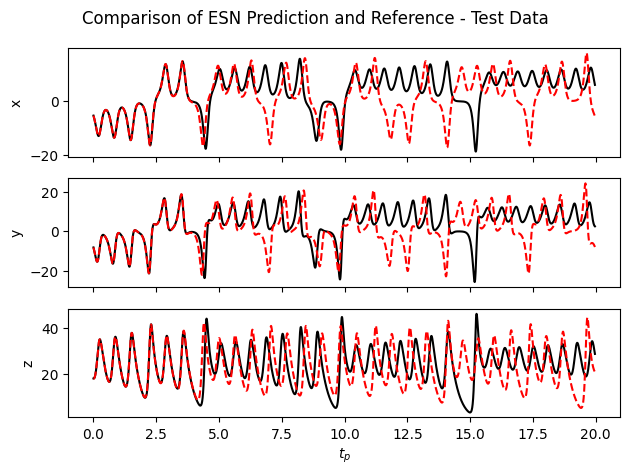

In [7]:
N_plot = 20 * N_lyap
# Define time steps
time_steps = np.arange(0, N_plot * dt, dt) / t_lyap

# Create a figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True)

for i in range(dim):
# Plot prediction and U_test for the third feature
    axes[i].plot(time_steps[:N_plot], U_test[:N_plot, i], color='black', label='Reference')
    axes[i].plot(time_steps[:N_plot], prediction[:N_plot, i], color='red', linestyle='dashed', label='ESN Prediction')

axes[0].set_ylabel("x")
axes[1].set_ylabel("y")
axes[2].set_ylabel("z")
axes[2].set_xlabel("$t_p$")

fig.suptitle("Comparison of ESN Prediction and Reference - Test Data")
plt.tight_layout()
# Show the plot
plt.show()

In [8]:
U_test.shape    

(97301, 3)

In [9]:

def stats_lorenz63(prediction_length, U_test_washout):
    reservoir, prediction = my_ESN.closed_loop_with_washout(U_test_washout, prediction_length)

    norm = np.max(U_rk4, axis=0)

    n_bins = 100
    x = np.linspace(-norm,norm,n_bins)

    fig, axs = plt.subplots(1,3, sharey=True, figsize=(8,2.5))

    fig.suptitle('Probability Density Function (PDF)')


    for i in range(dim):
        signal = U_test[:prediction_length,i]
        signal_p  = prediction[:prediction_length,i] #predicted closed loop
        kde = stats.gaussian_kde(signal)
        kde_p = stats.gaussian_kde(signal_p)
            
        axs[i].plot(x[:, i],kde(x[:, i]),color='black', label='Reference')
        axs[i].plot(x[:, i],kde_p(x[:, i]),color='blue', linestyle='dashed', label='ESN Prediction')

    axs[0].set_xlabel('$x$')
    axs[1].set_xlabel('$y$')
    axs[2].set_xlabel('$z$')
    plt.legend()    
    
    return(prediction)


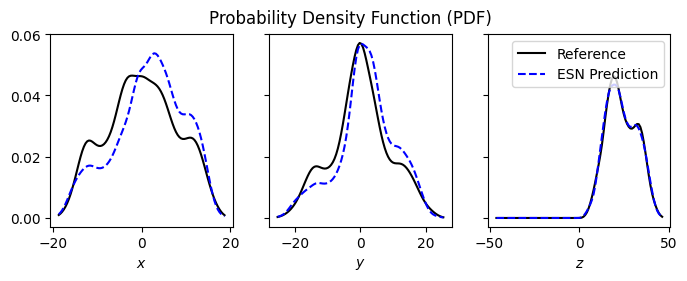

In [10]:
esn_prediction =stats_lorenz63(100*N_lyap, U_test_washout)

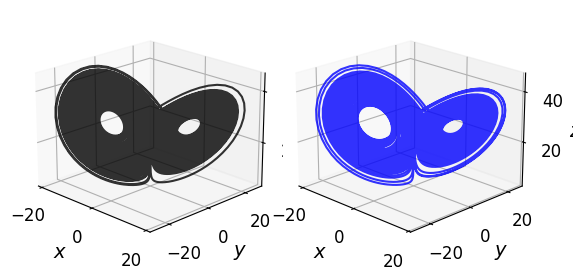

In [11]:
fs=14
fig = plt.figure(figsize=(8, 3))

# First subplot for U_rk4
ax1 = fig.add_subplot(131, projection='3d')

N_plot=20000
n = len(U_rk4[:N_plot])

ax1.plot(U_rk4[:n, 0], U_rk4[:n, 1], U_rk4[:n, 2], color='k', alpha=0.8)
ax1.view_init(elev=20, azim=-45)

ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_xlabel(r'$x$', fontsize=fs)
ax1.set_ylabel(r'$y$', fontsize=fs)
ax1.set_zlabel(r'$z$', fontsize=fs, labelpad=0)
# Second subplot for U_pred_lstm
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(esn_prediction[:n, 0], esn_prediction[:n, 1], esn_prediction[:n, 2], color='b', alpha=0.8)
ax2.view_init(elev=20, azim=-45)

ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_xlabel(r'$x$', fontsize=fs)
ax2.set_ylabel(r'$y$', fontsize=fs)
ax2.set_zlabel(r'$z$', fontsize=fs, labelpad=0)


# Adjust layout for better spacing
plt.subplots_adjust(left=-0.1, right=0.95, bottom=0.1, top=0.9, wspace=0.2)
plt.tight_layout()

In [12]:
def nrmse(pred: np.ndarray, df_test: np.ndarray, n_length: Optional[int] = None) -> float:
    """
    Compute the normalized root mean square error (NRMSE) between the network prediction and the ground truth.

    Arguments:
        pred (np.ndarray) : network prediction
        df_test (np.ndarray): ground truth values, e.g. from training data
        n_length (int, optional): length of the input sequence. If not specified, the length of the shorter input will be used

    Returns:
        The NRMSE value as a float.
    """
    if n_length == None:
        n_length = min(len(pred), df_test.shape[1])
    std = np.std(df_test[:, :n_length])
    diff = pred[:n_length, :] - df_test[:, :+n_length].T
    return np.sqrt(np.mean(diff**2 / std))

def valid_prediction_time(pred: np.ndarray, df_test: np.ndarray, threshold: float) -> int:
    """Calculate the "valid prediction time" (VPT) of a given prediction.
        The VPT is defined as the maximum number of consecutive time steps
        for which the NRMSE of the prediction is below a given threshold.
    Args:
        pred (np.ndarray): network prediction
        df_test (np.ndarray): reference data
        threshold (float):  NRMSE threshold

    Returns:
        int: NRMSE index
    """
    for i in range(1, len(pred)):
        nrmse_i = nrmse(pred, df_test, n_length=i)
        if nrmse_i > threshold:
            return i - 1
    return len(pred)

In [13]:
np.random.seed(123)
N_runs = 10
prediction_horizon = np.zeros(N_runs)
for i in range(N_runs):
    N_start = np.random.randint(len(U_test)-22*N_lyap)
    U_test_washout = U_test[N_start:N_start+washout_size , :]
    reservoir, prediction = my_ESN.closed_loop_with_washout(U_test_washout, 20*N_lyap)
    prediction_horizon[i] = time_steps[valid_prediction_time(prediction,  U_test[N_start+washout_size:, :].T, 0.4)]
print(f"Average prediction horizon in {np.mean(prediction)} in Lyapunov time")

Average prediction horizon in 8.625183479740523 in Lyapunov time
